In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
#reading the dataset 
df=pd.read_csv("apps.csv")
df.head()

,Sno,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sno             9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [7]:
#looking the  missing values
df.isnull().sum()

Sno                  0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [37]:
#filling the missing values
df.Rating.fillna(df.Rating.mean(),inplace=True)
df['Current Ver']=df['Current Ver'].fillna("Unknown")
df['Android Ver']=df['Android Ver'].fillna("Unknown")
df.dropna(inplace=True)
df.isnull().sum()

C:\Users\rohit\AppData\Local\Temp\ipykernel_15308\3012283738.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Rating.fillna(df.Rating.mean(),inplace=True)


Sno               0
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing ratings
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Clean Installs
df['Installs'] = df['Installs'].astype(str)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Price
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Save cleaned dataset
df.to_csv(
    "googleplaystore_cleaned.csv",
    index=False
)



googleplaystore_cleaned.csv saved successfully


In [12]:
df.describe()

,Sno,Rating,Reviews,Size
count,7021.000000,7021.000000,7.021000e+03,7021.000000
mean,5638.433984,4.160704,1.448960e+05,21.767597
std,3079.108366,0.559241,1.024428e+06,22.731237
min,0.000000,1.000000,1.000000e+00,0.000000
25%,3087.000000,4.000000,8.400000e+01,4.900000
50%,5716.000000,4.300000,1.546000e+03,13.000000
75%,8292.000000,4.500000,2.658700e+04,31.000000
max,10840.000000,5.000000,4.489172e+07,100.000000


In [13]:
#Top category
top_categories=df['Category'].value_counts().head(10)
top_categories


Category
FAMILY             1511
GAME                832
TOOLS               625
PERSONALIZATION     274
LIFESTYLE           269
MEDICAL             266
FINANCE             258
PRODUCTIVITY        223
BUSINESS            222
SPORTS              221
Name: count, dtype: int64

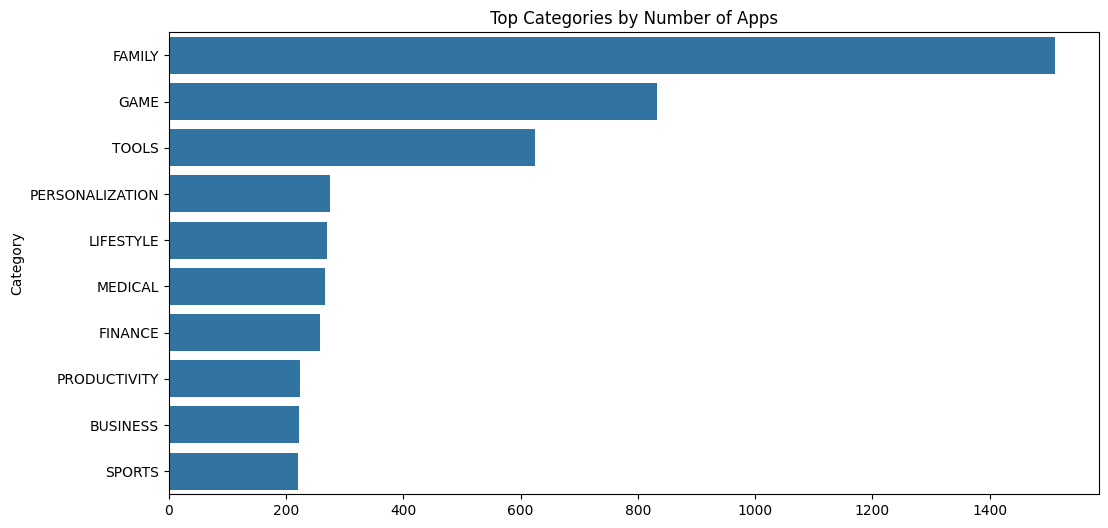

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.head(10).values,
    y=top_categories.head(10).index
)

plt.title("Top Categories by Number of Apps")

plt.show()

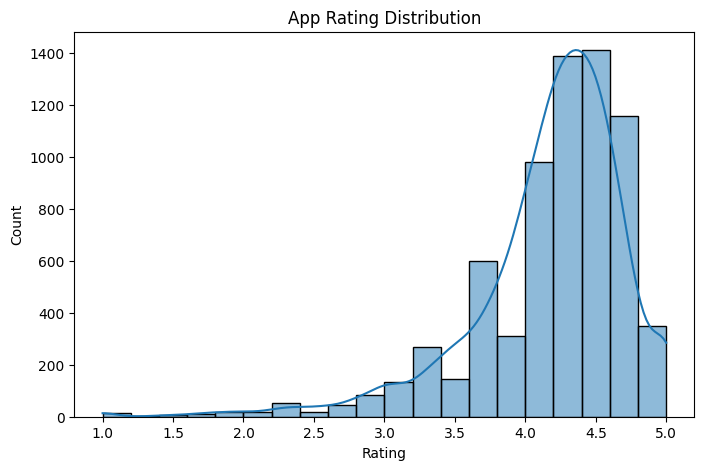

In [32]:
#rating
plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title("App Rating Distribution")

plt.show()

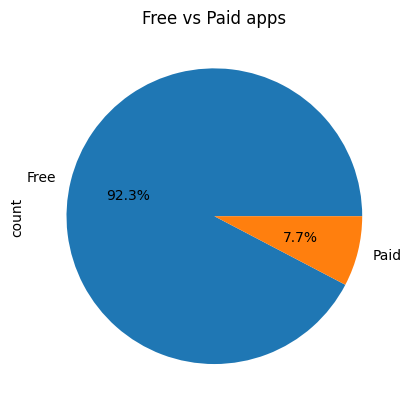

In [22]:
# free vs paid app
df['Type'].value_counts().plot(
    kind='pie',
   autopct='%1.1f%%')
plt.title("Free vs Paid apps")
plt.show()

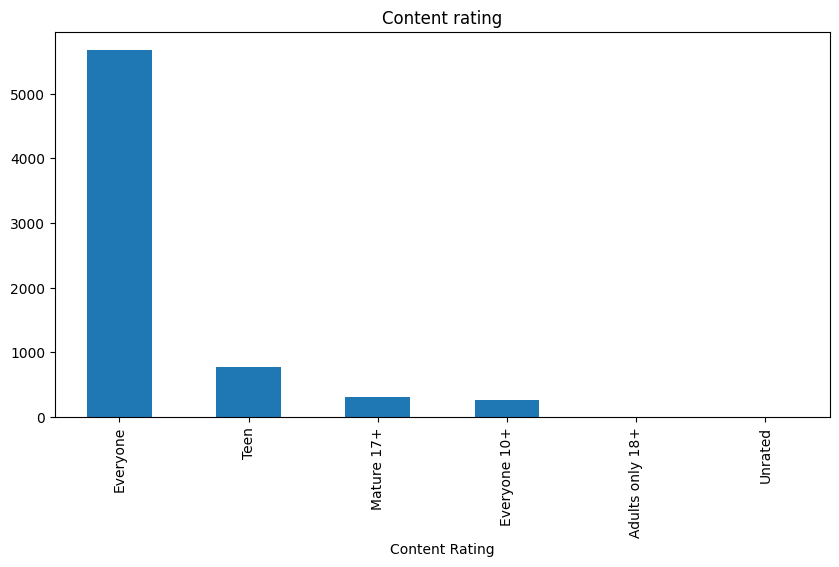

In [ ]:
#content rating
plt.figure(figsize=(10,5))
df['Content Rating'].value_counts().plot(kind='bar')
plt.xlabel("Content rating")
plt.ylabel("Number of apps")
plt.title("Content rating")
plt.show()

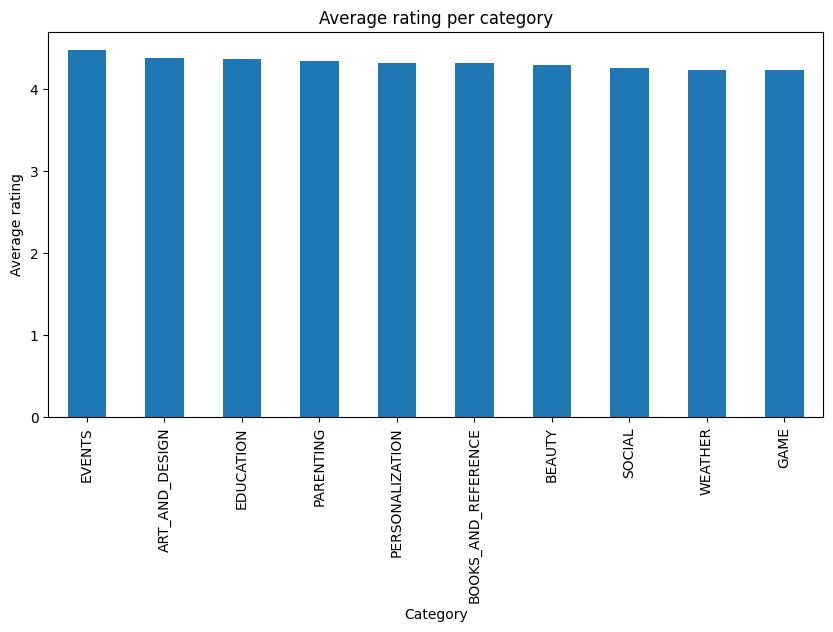

In [36]:
#avg rating per category
avg_ratings=df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
avg_ratings
plt.figure(figsize=(10,5))
avg_ratings.plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Average rating")
plt.title("Average rating per category")
plt.show()


In [69]:
genre = df[
    'Genres'
].value_counts().head(10)

genre

Genres
Tools              625
Entertainment      417
Education          391
Action             276
Personalization    274
Lifestyle          268
Medical            266
Finance            258
Sports             227
Productivity       223
Name: count, dtype: int64

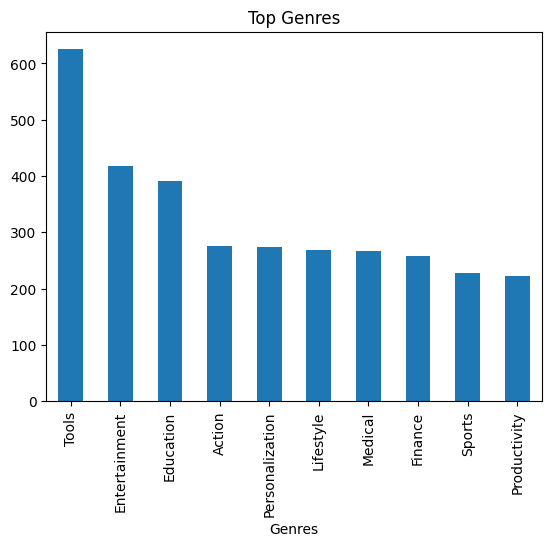

In [70]:
genre.plot(
    kind='bar'
)

plt.title(
    "Top Genres"
)

plt.show()

In [47]:
print(df[['Rating','Reviews','Installs','Price']].dtypes)

Rating      float64
Reviews       int64
Installs     object
Price        object
dtype: object


In [55]:
df['Installs'] = df['Installs'].astype(str)

df['Installs'] = (
    df['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [56]:
df['Price'] = df['Price'].astype(str)

df['Price'] = df['Price'].str.replace('$', '', regex=False)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [58]:
df['Installs'].dtypes, df['Price'].dtypes


(dtype('int64'), dtype('float64'))

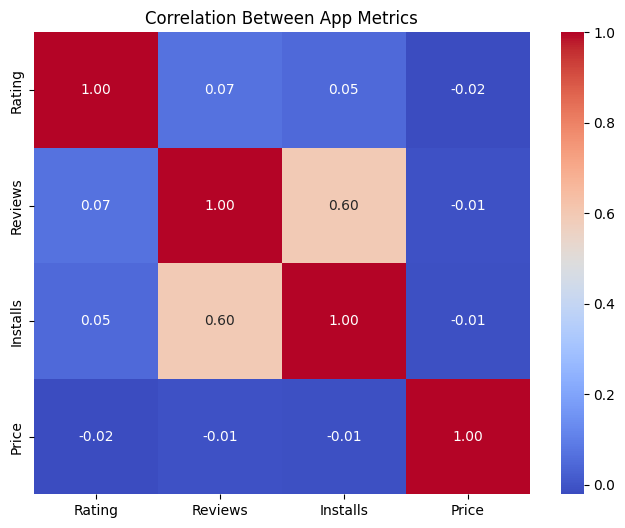

In [62]:

#correlation analysis
corr = df[['Rating','Reviews','Installs','Price']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between App Metrics")
plt.show()

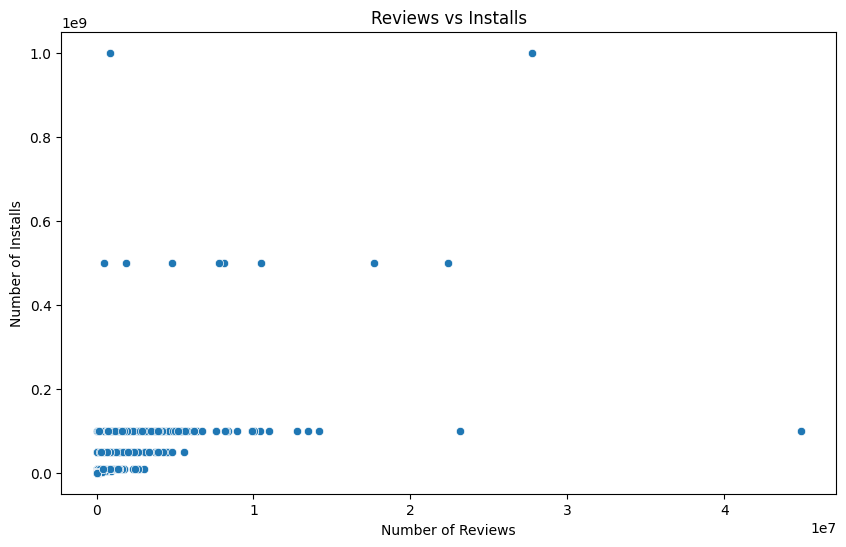

In [63]:
#Review vs Install Analysis
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Reviews',
    y='Installs'
)

plt.title("Reviews vs Installs")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Installs")

plt.show()

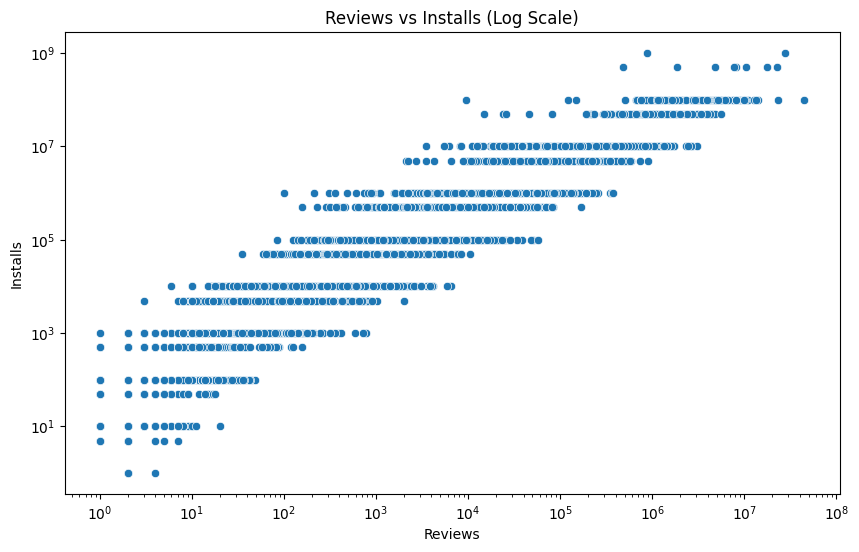

In [ ]:
#review vs install (log scale)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Reviews',
    y='Installs'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Reviews vs Installs (Log Scale)")
plt.xlabel("Reviews")
plt.ylabel("Installs")

plt.show()

In [65]:
correlation = df['Reviews'].corr(
    df['Installs']
)

print(
    "Correlation between Reviews and Installs:",
    round(correlation,3)
)

Correlation between Reviews and Installs: 0.596


In [ ]:

#top most reviewd apps
top_reviewed = df.sort_values(
    by='Reviews',
    ascending=False
)

top_reviewed[
    ['App','Reviews','Installs']
].head(10)

,App,Reviews,Installs
1372,Clash of Clans,44891723,100000000
1356,Subway Surfers,27722264,1000000000
1362,Clash Royale,23133508,100000000
1357,Candy Crush Saga,22426677,500000000
342,UC Browser - Fast Download Private & Secure,17712922,500000000
1377,8 Ball Pool,14198297,100000000
7778,DU Battery Saver - Battery Charger & Battery Life,13479633,100000000
2512,Cache Cleaner-DU Speed Booster (booster & clea...,12759663,100000000
1527,Shadow Fight 2,10979062,100000000
1364,Pou,10485308,500000000


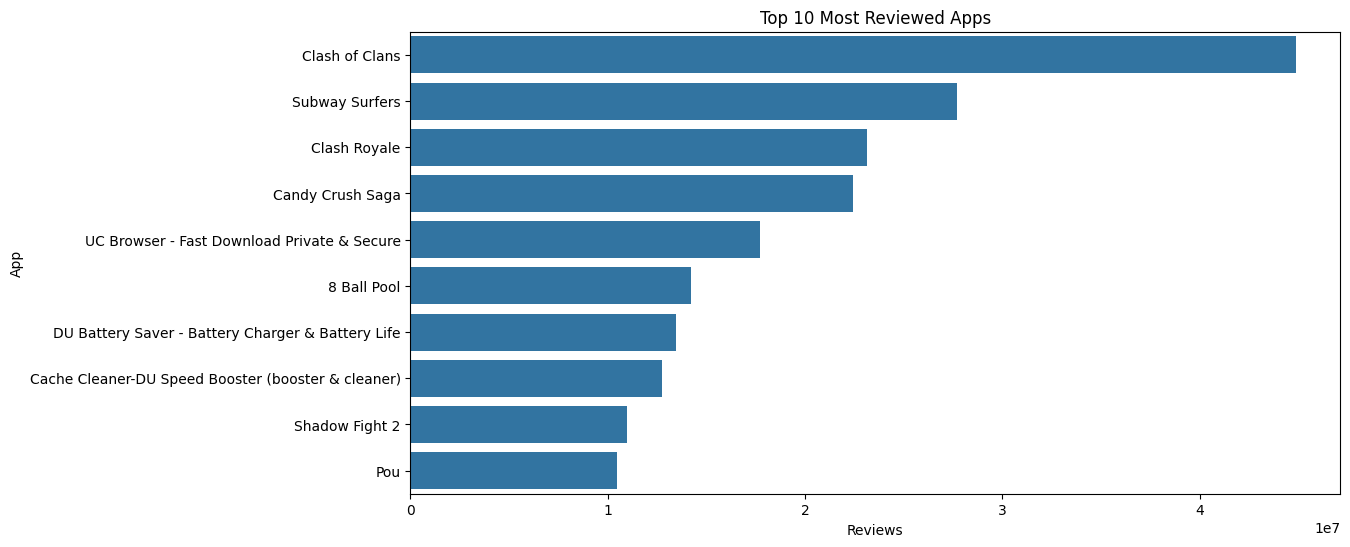

In [67]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_reviewed.head(10),
    x='Reviews',
    y='App'
)

plt.title("Top 10 Most Reviewed Apps")

plt.show()

In [8]:
#top installed apps
top_installs=df.sort_values('Installs',ascending=False).head(10)
top_installs


,Sno,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
342,378,UC Browser - Fast Download Private & Secure,COMMUNICATION,4.5,17712922,40.0,"500,000,000+",Free,0,Teen,Communication,"August 2, 2018",12.8.5.1121,4.0 and up
1410,1722,My Talking Tom,GAME,4.5,14891223,NaN,"500,000,000+",Free,0,Everyone,Casual,"July 19, 2018",4.8.0.132,4.1 and up
6486,7536,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,24900999,NaN,"500,000,000+",Free,0,Everyone,Tools,"August 4, 2018",4.6.6,Varies with device
2527,3255,SHAREit - Transfer & Share,TOOLS,4.6,7790693,17.0,"500,000,000+",Free,0,Everyone,Tools,"July 30, 2018",4.5.28_ww,4.1 and up
2508,3235,Google Translate,TOOLS,4.4,5745093,NaN,"500,000,000+",Free,0,Everyone,Tools,"August 4, 2018",Varies with device,Varies with device
2004,2546,Facebook Lite,SOCIAL,4.3,8606259,NaN,"500,000,000+",Free,0,Teen,Social,"August 1, 2018",Varies with device,Varies with device
4623,5596,Samsung Health,HEALTH_AND_FITNESS,4.3,480208,70.0,"500,000,000+",Free,0,Everyone,Health & Fitness,"July 31, 2018",5.17.2.009,5.0 and up
335,371,Google Duo - High Quality Video Calls,COMMUNICATION,4.6,2083237,NaN,"500,000,000+",Free,0,Everyone,Communication,"July 31, 2018",37.1.206017801.DR37_RC14,4.4 and up
2008,2550,Snapchat,SOCIAL,4.0,17014787,NaN,"500,000,000+",Free,0,Teen,Social,"July 30, 2018",Varies with device,Varies with device
2537,3265,Gboard - the Google Keyboard,TOOLS,4.2,1859115,NaN,"500,000,000+",Free,0,Everyone,Tools,"July 31, 2018",Varies with device,Varies with device


In [27]:
#Sentimental Analysis
review=pd.read_csv("user_reviews.csv")
review.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [74]:
review.info()

review.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


(64295, 5)

In [ ]:
review.isnull().sum()
review = review.dropna()

review.shape


(37427, 5)

In [34]:
# Remove missing values
review = review.dropna()

# Remove duplicates
review = review.drop_duplicates()

# Reset index
review = review.reset_index(drop=True)

# Save cleaned reviews dataset
review.to_csv(
    "user_reviews_cleaned.csv",
    index=False
)


In [78]:
#sentiment distribution

sentiment = review['Sentiment'].value_counts()

sentiment

Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

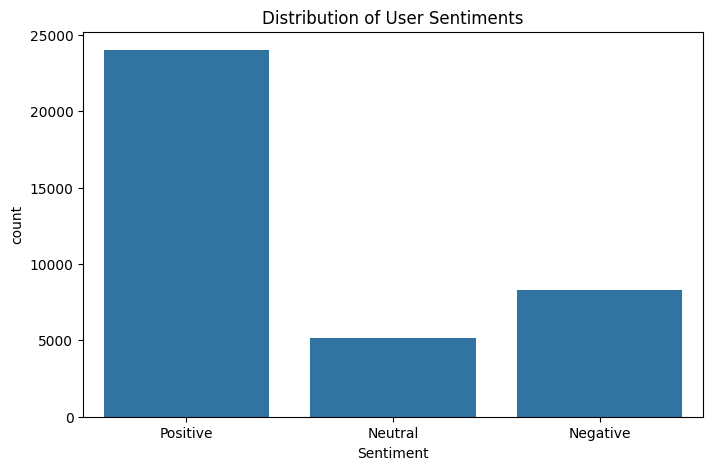

In [80]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=review,
    x='Sentiment'
)

plt.title("Distribution of User Sentiments")

plt.show()

In [82]:
sentiment_percentage = (
    review['Sentiment']
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentage)

Sentiment
Positive    64.119486
Negative    22.099019
Neutral     13.781495
Name: proportion, dtype: float64


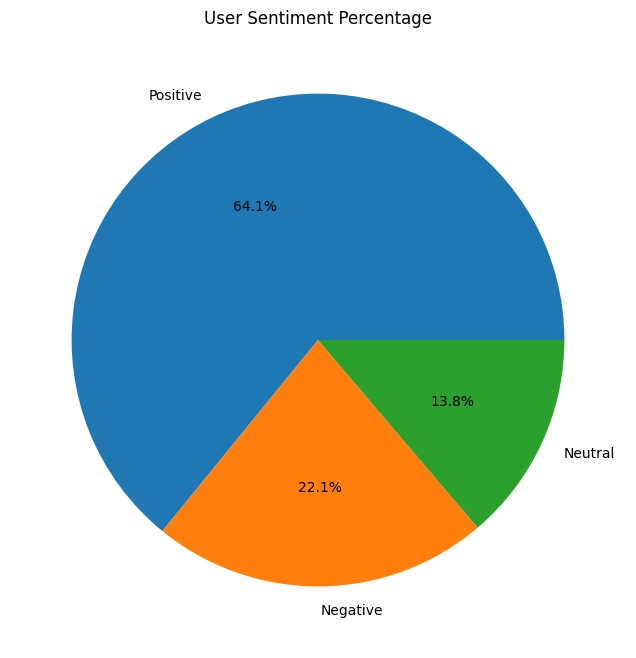

In [84]:
plt.figure(figsize=(8,8))

plt.pie(
    sentiment_percentage,
    labels=sentiment_percentage.index,
    autopct='%1.1f%%'
)

plt.title("User Sentiment Percentage")

plt.show()

In [88]:
review.columns


Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [97]:
positive_apps = review[
    review['Sentiment'] == 'Positive'
]

positive_apps['App'].value_counts().head(10)

App
Helix Jump                        209
Duolingo: Learn Languages Free    200
Calorie Counter - Macros          174
Calorie Counter - MyFitnessPal    169
Bowmasters                        169
10 Best Foods for You             162
Google Photos                     143
8fit Workouts & Meal Planner      137
Garena Free Fire                  136
DRAGON BALL LEGENDS               127
Name: count, dtype: int64

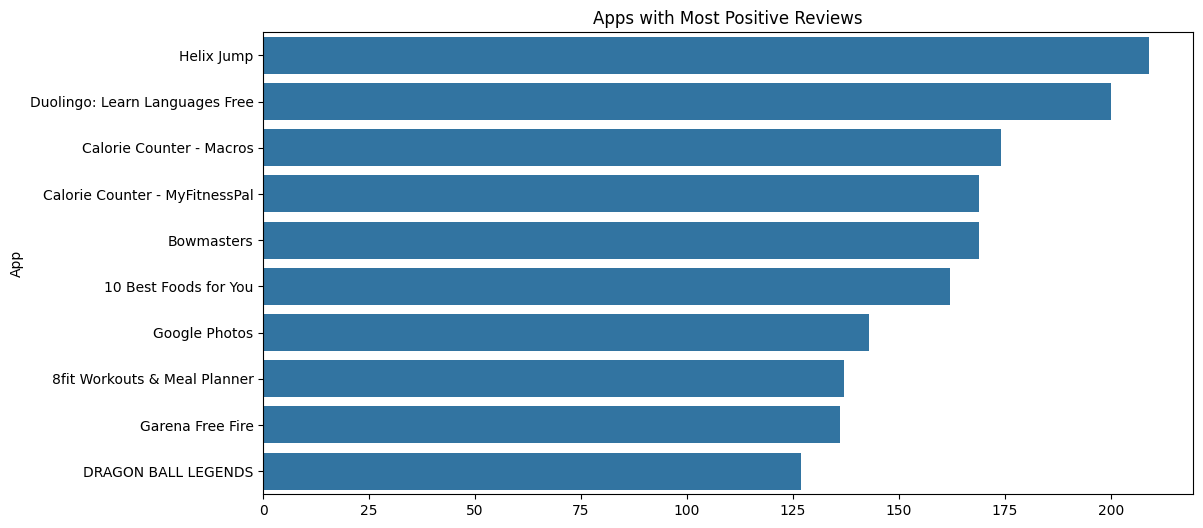

In [98]:
top_positive = positive_apps[
    'App'
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_positive.values,
    y=top_positive.index
)

plt.title("Apps with Most Positive Reviews")

plt.show()

In [93]:
negative_apps = review[
    review['Sentiment'] == 'Negative'
]

negative_apps['App'].value_counts().head(10)

App
Angry Birds Classic      147
Candy Crush Saga         126
Bowmasters               119
8 Ball Pool              106
Candy Crush Soda Saga     96
Garena Free Fire          81
Cooking Fever             79
Alto's Adventure          72
Block Puzzle              71
Agar.io                   66
Name: count, dtype: int64

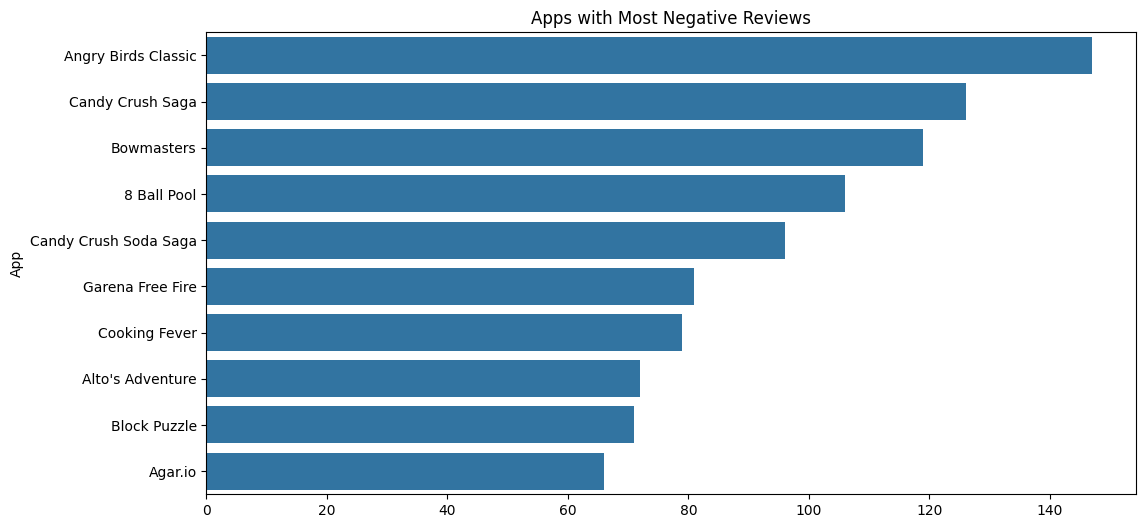

In [94]:
top_negative = negative_apps[
    'App'
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_negative.values,
    y=top_negative.index
)

plt.title("Apps with Most Negative Reviews")

plt.show()

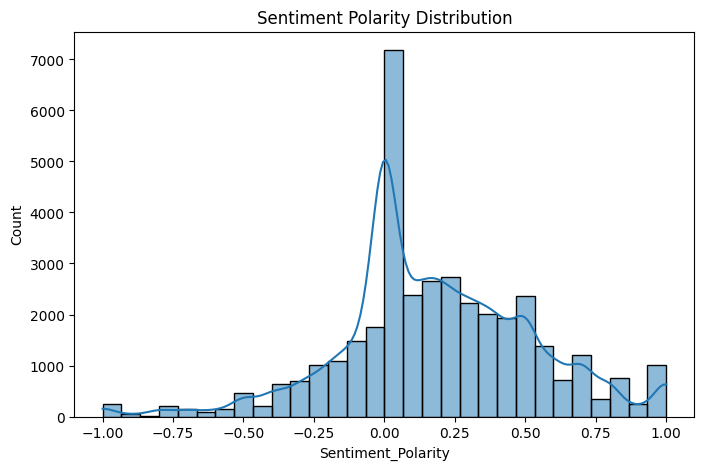

In [100]:
#sentiment polarity analysis
plt.figure(figsize=(8,5))

sns.histplot(
    review['Sentiment_Polarity'],
    bins=30,
    kde=True
)

plt.title("Sentiment Polarity Distribution")

plt.show()

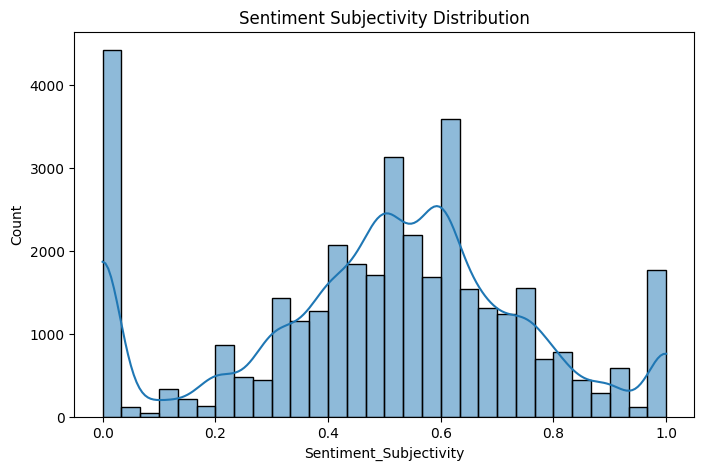

In [102]:
#sentiment subjectivity analysis

plt.figure(figsize=(8,5))

sns.histplot(
    review['Sentiment_Subjectivity'],
    bins=30,
    kde=True
)

plt.title("Sentiment Subjectivity Distribution")

plt.show()

In [28]:
merged_df = pd.merge(
    df,
    review,
    on='App',
    how='inner'
)

merged_df.head()

,Sno,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
4,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000


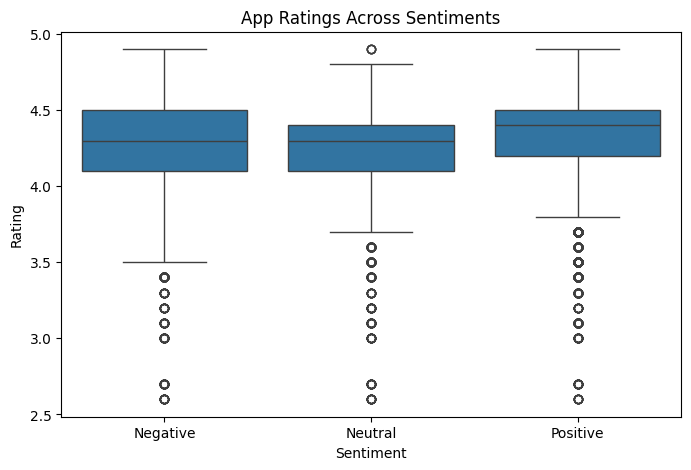

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x='Sentiment',
    y='Rating'
)

plt.title("App Ratings Across Sentiments")

plt.show()

In [30]:
category_sentiment = merged_df.groupby(
    'Category'
)['Sentiment_Polarity'].mean()

category_sentiment.sort_values(
    ascending=False
).head(10)

Category
COMICS                 0.440031
EVENTS                 0.377933
AUTO_AND_VEHICLES      0.348683
PARENTING              0.318880
WEATHER                0.294978
HEALTH_AND_FITNESS     0.290694
EDUCATION              0.279332
PERSONALIZATION        0.278213
MAPS_AND_NAVIGATION    0.267218
FOOD_AND_DRINK         0.266882
Name: Sentiment_Polarity, dtype: float64

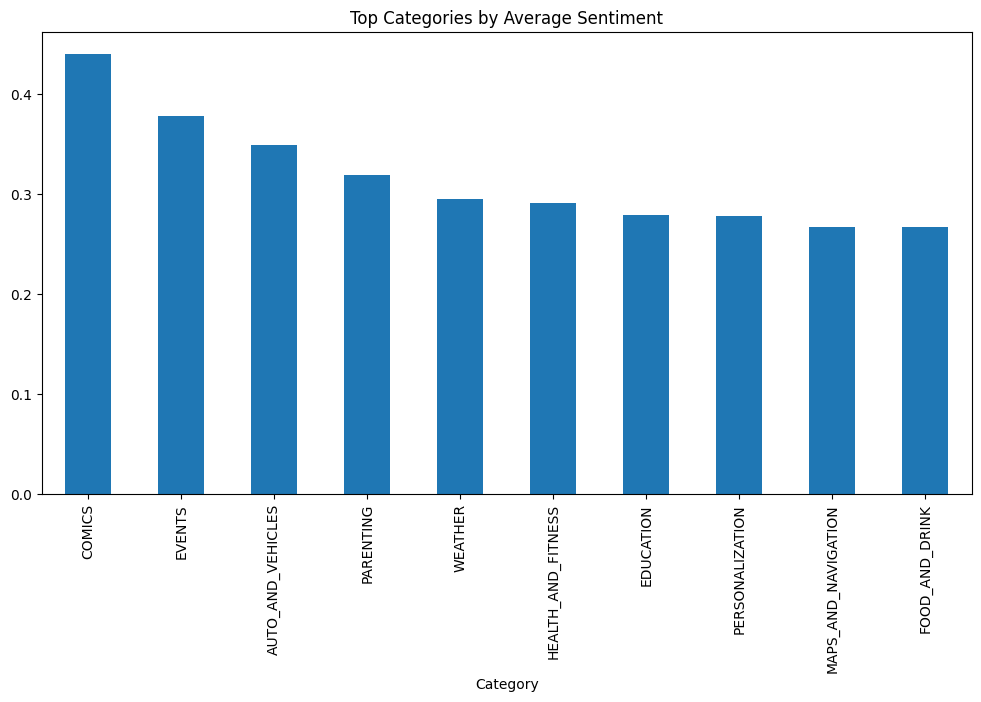

In [31]:
plt.figure(figsize=(12,6))

category_sentiment.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title(
    "Top Categories by Average Sentiment"
)

plt.show()

In [103]:
print("""
SENTIMENT ANALYSIS INSIGHTS

1. Positive reviews dominate the dataset.

2. Apps with higher ratings generally receive
more positive sentiments.

3. Certain categories receive consistently
better user feedback.

4. Negative reviews highlight areas where
developers can improve app quality.

5. Sentiment analysis provides deeper insight
than ratings alone.
""")


SENTIMENT ANALYSIS INSIGHTS

1. Positive reviews dominate the dataset.

2. Apps with higher ratings generally receive
more positive sentiments.

3. Certain categories receive consistently
better user feedback.

4. Negative reviews highlight areas where
developers can improve app quality.

5. Sentiment analysis provides deeper insight
than ratings alone.

